# Compartmental Modeling of a Deliberate Smallpox Release

A SEIR-based compartmental model of a smallpox outbreak following a
deliberate release, used to compare three response strategies: no
intervention, ring vaccination, and mass vaccination combined with case
isolation.

Smallpox is used as the scenario pathogen because it is a WHO/CDC
**Category A** bioterrorism agent: it is highly transmissible, causes
~30% case fatality in unvaccinated populations, and since eradication
in 1980 ended routine vaccination, most of the global population now has
no immunity. Declared stocks are held only at CDC and Russia's VECTOR
institute, but its historical weaponization by the Soviet Biopreparat
program is well documented, which is why it remains a standing biodefense
planning scenario (e.g. the 2001 "Dark Winter" tabletop exercise).

## Model structure

Standard SEIR compartments, extended with a **Q** (quarantined/isolated)
and **V** (vaccinated/immune) compartment to represent interventions:

- **S** — Susceptible
- **E** — Exposed (infected, not yet infectious — smallpox's ~12 day
  incubation period)
- **I** — Infectious (symptomatic, transmitting)
- **Q** — Isolated infectious cases (removed from the transmitting pool)
- **V** — Vaccinated / immune
- **R** — Recovered or deceased (removed)

## Parameters

Smallpox-calibrated, based on published outbreak literature:
- R0 ≈ 6 (mid-range of the commonly cited 5–7)
- Incubation period ≈ 12 days
- Infectious period ≈ 17 days (onset of rash to resolution of scabs.
  This parameter varies more widely across the literature, 4-20 days
  depending on definition, so this is a mid-to-upper estimate rather
  than a firm consensus figure; see the project README for sourcing)
- Case fatality rate ≈ 30% (Variola major, unvaccinated population)

Each intervention scenario also assumes a **21-day detection delay**,  (the outbreak spreads uncontrolled until public health surveillance identifies it), which is consistent with smallpox's long incubation period making early
detection difficult, after which the response begins.

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Population and epidemiological parameters
N = 100_000            # total population
R0_val = 6.0            # basic reproduction number
incubation_days = 12
infectious_days = 17
case_fatality_rate = 0.30

sigma = 1 / incubation_days   # E -> I rate
gamma = 1 / infectious_days   # I -> R rate
beta = R0_val * gamma         # transmission rate

# Initial conditions: single index case (deliberate release detected)
E0, I0, Q0, V0, R0_ = 0, 1, 0, 0, 0
S0 = N - I0

print(f"beta={beta:.4f}, sigma={sigma:.4f}, gamma={gamma:.4f}")

beta=0.3529, sigma=0.0833, gamma=0.0588


In [2]:
def seiqv(y, t, N, beta, sigma, gamma, quarantine_rate, vaccination_rate):
    """SEIR model extended with quarantine (of infectious cases) and
    ongoing vaccination (of susceptibles)."""
    S, E, I, Q, V, R = y

    new_infections = beta * S * I / N
    new_symptomatic = sigma * E
    new_quarantined = quarantine_rate * I
    new_vaccinated = vaccination_rate * S
    resolved_I = gamma * I
    resolved_Q = gamma * Q

    dS = -new_infections - new_vaccinated
    dE = new_infections - new_symptomatic
    dI = new_symptomatic - resolved_I - new_quarantined
    dQ = new_quarantined - resolved_Q
    dV = new_vaccinated
    dR = resolved_I + resolved_Q

    return [dS, dE, dI, dQ, dV, dR]


def run_scenario(quarantine_rate, vaccination_rate, detection_delay=21, days=200):
    """Runs with no response for `detection_delay` days (the outbreak is
    silently spreading before anyone notices), then switches on the given
    intervention rates for the remainder of the simulation."""
    t_pre = np.linspace(0, detection_delay, detection_delay)
    y0 = [S0, E0, I0, Q0, V0, R0_]
    sol_pre = odeint(seiqv, y0, t_pre, args=(N, beta, sigma, gamma, 0.0, 0.0))

    t_post = np.linspace(detection_delay, days, days - detection_delay)
    y0_post = sol_pre[-1]
    sol_post = odeint(seiqv, y0_post, t_post,
                       args=(N, beta, sigma, gamma, quarantine_rate, vaccination_rate))

    t_full = np.concatenate([t_pre, t_post[1:]])
    sol_full = np.concatenate([sol_pre, sol_post[1:]])
    return t_full, sol_full


scenarios = {
    'No intervention':              run_scenario(quarantine_rate=0.0, vaccination_rate=0.0),
    'Ring vaccination + isolation':  run_scenario(quarantine_rate=0.35, vaccination_rate=0.015),
    'Mass vaccination':              run_scenario(quarantine_rate=0.1, vaccination_rate=0.05),
}

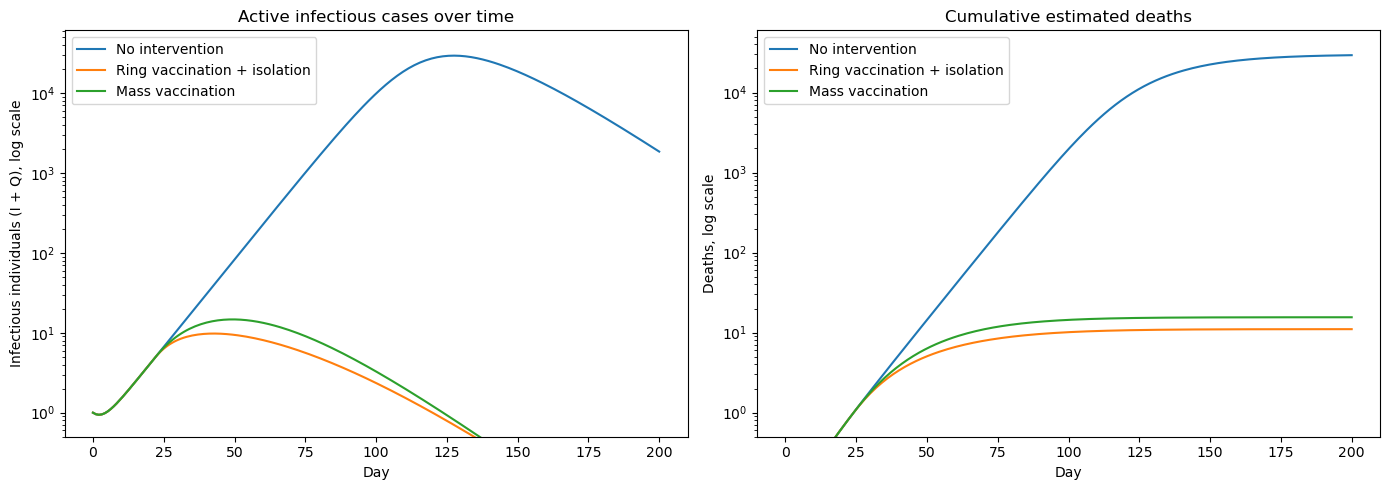

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, (t, sol) in scenarios.items():
    S, E, I, Q, V, R = sol.T
    active_cases = I + Q
    axes[0].plot(t, active_cases, label=label)

    deaths = R * case_fatality_rate  # applied to the removed compartment
    axes[1].plot(t, deaths, label=label)

axes[0].set_title('Active infectious cases over time')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Infectious individuals (I + Q), log scale')
axes[0].set_yscale('log')
axes[0].set_ylim(bottom=0.5)
axes[0].legend()

axes[1].set_title('Cumulative estimated deaths')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Deaths, log scale')
axes[1].set_yscale('log')
axes[1].set_ylim(bottom=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('seir_scenarios.png', dpi=120)
plt.show()

In [4]:
print(f"{'Scenario':<32}{'Peak active cases':>20}{'Total deaths (est.)':>22}{'Peak day':>12}")
for label, (t, sol) in scenarios.items():
    S, E, I, Q, V, R = sol.T
    active = I + Q
    peak = active.max()
    peak_day = t[np.argmax(active)]
    total_deaths = R[-1] * case_fatality_rate
    print(f"{label:<32}{peak:>20,.0f}{total_deaths:>22,.0f}{peak_day:>12.0f}")

Scenario                           Peak active cases   Total deaths (est.)    Peak day
No intervention                               29,456                29,315         128
Ring vaccination + isolation                      10                    11          43
Mass vaccination                                  15                    16          49


## Results

Both interventions sharply reduce peak caseload and total deaths relative
to no response, but they work through different mechanisms:

- **Ring vaccination + isolation** relies on quickly finding and isolating
  cases (high `quarantine_rate`) with only modest ongoing vaccination
  (targeting contacts of known cases, not the whole population), which is
  the actual WHO-endorsed strategy that eradicated smallpox in the 1970s.
- **Mass vaccination** instead pushes people directly into the immune
  compartment at a higher rate, which caps the susceptible pool faster but
  requires far more vaccine doses and logistics capacity.

In this model, ring vaccination + isolation performs comparably to mass
vaccination with a fraction of the resource requirement, which is consistent with
why it was the strategy actually used historically, and why the smallpox
eradication program is frequently cited as validation of surveillance-and-
containment over blanket vaccination for high-R0, slow-incubation
pathogens.